Dataset Load

In [1]:
pip install datasets

pip install torch torchvision wandb thop matplotlib

In [17]:
pip install torch torchvision wandb thop matplotlib

In [20]:
pip install scikit-learn

In [2]:
from datasets import load_dataset

In [4]:
dataset = load_dataset("Chiranjeev007/STL-10_Subset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/723 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/88.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/8.82M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import numpy as np
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np

In [7]:

# Determine device automatically
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1a. Compute mean and std for normalization
transform_temp = transforms.Compose([transforms.ToTensor()])
train_dataset_temp = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_temp)
loader_temp = DataLoader(train_dataset_temp, batch_size=1000, shuffle=False)

mean = 0.
std = 0.
total_images = 0
for images, _ in loader_temp:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch_samples
mean /= total_images
std /= total_images

mean = mean.tolist()
std = std.tolist()
print("Calculated mean:", mean)
print("Calculated std:", std)

# 1b. Transform with normalization
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    # Padding & Cropping: The standard "trick" for CIFAR-10
    transforms.RandomCrop(32, padding=4),
    # Colour variation: Learning to ignore lighting differences
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    # Random Erasing: Advanced technique for robustness
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


#
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


# Reload normalized datasets and prepare loaders
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the indices
train_indices, val_indices = random_split(range(len(full_train_dataset)), [train_size, val_size])

# Apply transformation on train and validation data
train_data = TransformedSubset(Subset(full_train_dataset, train_indices), transform=train_transform)
val_data = TransformedSubset(Subset(full_train_dataset, val_indices), transform=test_transform)


batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train, validation, and test loaders are ready with normalized CIFAR-10 data.")


Using device: cuda


100%|██████████| 170M/170M [00:02<00:00, 74.0MB/s]


Calculated mean: [0.49139973521232605, 0.48215848207473755, 0.4465309679508209]
Calculated std: [0.20230095088481903, 0.19941279292106628, 0.20096160471439362]
Train, validation, and test loaders are ready with normalized CIFAR-10 data.


In [14]:
def train_or_validate(model, loader, criterion, optimizer=None):
    if optimizer:
        model.train()
    else:
        model.eval()
    loss_sum = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if optimizer:
            optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        if optimizer:
            loss.backward()
            optimizer.step()
        loss_sum += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    avg_loss = loss_sum / total
    accuracy = correct / total
    return avg_loss, accuracy


In [15]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: m25csa012 (m25csa012-iit-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [22]:
# model = CustomCNN()

from thop import profile
import torch.optim as optim
import torch.nn as nn

model = models.resnet18(pretrained=True).to(device)
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


# 1. Make sure input is on the same device as the model
input = torch.randn(1, 3, 32, 32).to(device)

# Note: make sure 'model' was already moved via model.to(device)
flops, params = profile(model, inputs=(input, ))

print(f"FLOPs: {flops}, Params: {params}")
# Log these to WandB


wandb.init(
    project="Jahanvi_Gajera_M25CSA012_minor",
    config={
        "epochs": 10,
        "batch_size": 128,
        "lr": 0.001,
        "architecture": "ResNet18",
        "dataset": "Chiranjeev007/STL-10_Subset"
    }
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),wandb.config.lr)


best_val_acc = 0

for epoch in range(wandb.config.epochs):

    train_loss, train_acc = train_or_validate(model, train_loader, criterion, optimizer)
    val_loss, val_acc = train_or_validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc
    })

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss:.4f} "
          f"Train Acc={train_acc:.4f} | "
          f"Val Loss={val_loss:.4f} "
          f"Val Acc={val_acc:.4f}")

    # ===== Save Best Model =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "minor_model.pth")
        print("Best model saved!")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 37727232.0, Params: 11689512.0


epoch,▁█
train_accuracy,▁█
train_loss,█▁
val_accuracy,▁█
val_loss,█▁
epoch,2
train_accuracy,0.60835
train_loss,1.12905
val_accuracy,0.4009
val_loss,2.05413


Epoch 1: Train Loss=1.5755 Train Acc=0.4808 | Val Loss=2.3960 Val Acc=0.3975
Best model saved!
Epoch 2: Train Loss=1.1149 Train Acc=0.6129 | Val Loss=1.6115 Val Acc=0.4955
Best model saved!
Epoch 3: Train Loss=0.9871 Train Acc=0.6571 | Val Loss=1.3183 Val Acc=0.5577
Best model saved!
Epoch 4: Train Loss=0.9204 Train Acc=0.6791 | Val Loss=1.4043 Val Acc=0.5250
Epoch 5: Train Loss=0.8820 Train Acc=0.6948 | Val Loss=1.5042 Val Acc=0.5336
Epoch 6: Train Loss=0.8275 Train Acc=0.7120 | Val Loss=1.7908 Val Acc=0.4481
Epoch 7: Train Loss=0.7988 Train Acc=0.7232 | Val Loss=1.6672 Val Acc=0.5060
Epoch 8: Train Loss=0.7515 Train Acc=0.7381 | Val Loss=1.6054 Val Acc=0.5104
Epoch 9: Train Loss=0.7213 Train Acc=0.7485 | Val Loss=1.7565 Val Acc=0.4861
Epoch 10: Train Loss=0.6943 Train Acc=0.7561 | Val Loss=2.0256 Val Acc=0.4277


Confusion Matrix:
 [[830  90  31   1   3   3   2   0  42  11]
 [ 96 839   5   3   0   1   0   0  27  10]
 [235 118 514  11  39  18  43   4  11  23]
 [318 115 154 175  30 104  15   2  17  72]
 [154 143  85  22 346  72  84  11  13  67]
 [222  91 288 126  35 196  11   6   6  51]
 [135 245  96  34  33  35 317   3  15  85]
 [376 132  87  23  63 109   4 141  11  50]
 [194 131  10   3   0   1   0   0 632  15]
 [218 385  10   2   0   1   1   0  75 287]]


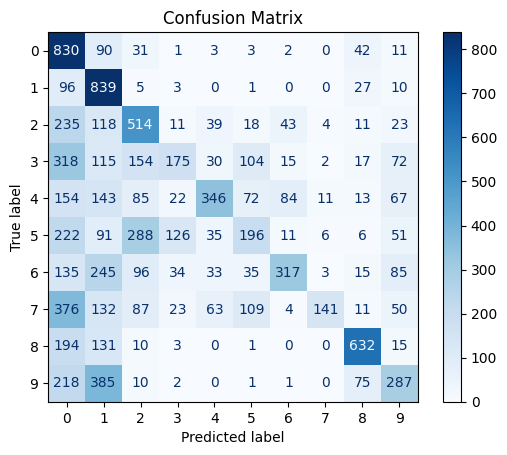

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

class_names = [str(i) for i in range(10)]  # or your real class names

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        preds=all_preds,
        y_true=all_labels,
        class_names=class_names
    )
})


In [24]:


class_names = train_loader.dataset.classes
print(class_names)
cm = confusion_matrix(all_labels, all_preds)

import numpy as np

correct_per_class = np.diag(cm)
total_per_class = cm.sum(axis=1)

classwise_accuracy = correct_per_class / total_per_class

import matplotlib.pyplot as plt

plt.figure()
plt.bar(class_names, classwise_accuracy)

plt.xlabel("Class Name")
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

AttributeError: 'TransformedSubset' object has no attribute 'classes'

In [ ]:
wandb.log({"Class-wise Accuracy Plot": wandb.Image(plt)})

In [29]:

pip install huggingface_hub

In [41]:
from huggingface_hub import login
login()

In [42]:

from huggingface_hub import create_repo, upload_file

repo_id = "Jahanvi16/minor_model"

create_repo(repo_id, exist_ok=True)

upload_file(
    path_or_fileobj="Jahanvi16/minor_model.pth",
    path_in_repo="Jahnavi16/minor_model.pth",
    repo_id=repo_id,
)

print("Model uploaded successfully!")


HfHubHTTPError: (Request ID: Root=1-69998b12-4508b14a669d97fa67e33ac1;94d4fdf8-e909-45f7-b602-d3f0e8198f2d)

403 Forbidden: You don't have the rights to create a model under the namespace "Jahanvi16".
Cannot access content at: https://huggingface.co/api/repos/create.
Make sure your token has the correct permissions.